## 1 Create the training and validation datasets
### 1.1 Load the data


In [2]:
import pickle

# Validate algorithm against training project data with known m-heights
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    training_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    expected_heights = pickle.load(f)

#Create a 70/30 random training/validation split
from sklearn.model_selection import train_test_split
train_data, val_data, train_heights, val_heights = train_test_split(training_data, expected_heights, test_size=0.3, random_state=42)



### 1.2 Pre-process the data
n=9
k is in [4,5,6]
m is in [2,..,n-k]

So we have 9 combinations for n,k,m
1 n = 9 , k = 4 , m = 2
2. n = 9 , k = 4 , m = 3
3. n = 9 , k = 4 , m = 4
4. n = 9 , k = 4 , m = 5
5. n = 9 , k = 5 , m = 2
6. n = 9 , k = 5 , m = 3
7. n = 9 , k = 5 , m = 4
8. n = 9 , k = 6 , m = 2
9. n = 9 , k = 6 , m = 3

P is a 2-dimensional numpy array of k rows and n-k columns

We need to normalize and convert this data into a single tensor of 37 dimensions (3 for k values + 4 for m values + 30 for P)

In [3]:
#We need to convert the training data into a format suitable for our algorithm. Assuming the training data is in the form of a list of tuples (n, k, m, P), we can extract the features and labels as follows:
#Normalize the values in P (from -100 to 100) to be between 0 and 1
#Because n is always 9, we can ignore it as a feature
import numpy as np
import tensorflow as tf

#K can be 4, 5, or 6 for our case
def one_hot_encode_k(k):
    if k == 4:
        return [1, 0, 0]
    elif k == 5:
        return [0, 1, 0]
    elif k == 6:
        return [0, 0, 1]
    else:
        raise ValueError("Invalid value for k: {}".format(k))
#m can be 2-5 for our case    
def one_hot_encode_m(m):
    if m == 2:
        return [1, 0, 0, 0]
    elif m == 3:
        return [0, 1, 0, 0]
    elif m == 4:
        return [0, 0, 1, 0]
    elif m == 5:
        return [0, 0, 0, 1]
    else:
        raise ValueError("Invalid value for m: {}".format(m))

def preprocess_P(P, k, n=9):
    P = (P + 100) / 200.0
    # Pad to max size: 6 rows x 5 cols = 30
    P_pad = np.zeros((6, 5))
    P_pad[:k, :n-k] = P
    return P_pad.flatten()  # always 30 values   

def preprocess_labels(heights):
    # Log transform the heights to make them more suitable for regression
    # In case of log(0) or log of negative numbers, we can add a small constant to the heights before taking the log
    heights = np.array(heights)
    heights = heights + 1e-6  # Add a small constant to avoid log(0)
    heights = np.log(heights)  
    return heights

def preprocess_features(data):
    features = []
    for n, k, m, P in data:
        feat = np.concatenate([one_hot_encode_k(k), one_hot_encode_m(m), preprocess_P(P, k, n)])
        features.append(feat)
    return np.array(features, dtype=np.float32)  # shape: (N, 37)
 
X_train, y_train = preprocess_features(train_data), preprocess_labels(train_heights)
X_val, y_val = preprocess_features(val_data), preprocess_labels(val_heights)

#Print shapes to verify
print("Training features shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation features shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

#Print sample features and labels to verify
print("Sample training features (first 5):", X_train[:5])
print("Sample training labels (first 5):", y_train[:5])

# Build tf.data pipelines: cache keeps data in GPU memory, prefetch overlaps
# CPU batch prep with GPU training to keep the GPU fully fed
BATCH_SIZE = 4096
ds_train = (tf.data.Dataset.from_tensor_slices((X_train, y_train.astype('float32')))
            .cache()
            .shuffle(len(X_train), seed=42)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))
ds_val = (tf.data.Dataset.from_tensor_slices((X_val, y_val.astype('float32')))
          .cache()
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
print(f"\nDatasets built with BATCH_SIZE={BATCH_SIZE}: "
      f"{len(ds_train)} train batches, {len(ds_val)} val batches per epoch")


2026-03-12 00:33:23.708507: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 00:33:23.904697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-12 00:33:23.980046: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-12 00:33:24.004051: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 00:33:24.124553: I tensorflow/core/platform/cpu_feature_guar

Training features shape: (67566, 37)
Training labels shape: (67566,)
Validation features shape: (28958, 37)
Validation labels shape: (28958,)
Sample training features (first 5): [[0.    0.    1.    0.    1.    0.    0.    0.28  0.39  0.515 0.    0.
  0.275 0.61  0.41  0.    0.    0.66  0.295 0.305 0.    0.    0.535 0.59
  0.3   0.    0.    0.34  0.53  0.605 0.    0.    0.295 0.425 0.425 0.
  0.   ]
 [1.    0.    0.    1.    0.    0.    0.    0.705 0.85  0.295 0.5   0.825
  0.335 0.485 0.61  0.435 0.475 0.42  0.36  0.595 0.5   0.39  0.495 0.365
  0.435 0.715 0.33  0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.    0.    1.    1.    0.    0.    0.    0.3   0.955 0.12  0.    0.
  0.65  0.445 0.675 0.    0.    0.28  0.665 0.145 0.    0.    0.615 0.84
  0.325 0.    0.    0.22  0.99  0.435 0.    0.    0.865 0.825 0.415 0.
  0.   ]
 [1.    0.    0.    0.    0.    1.    0.    0.9   0.845 0.255 0.895 0.91
  0.92  0.315 0.91  0.825 0.425 0.225 0.9   0.35  0.28  0.285 0.36  0.43


I0000 00:00:1773275607.066624    1309 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773275607.372725    1309 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773275607.372764    1309 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773275607.376452    1309 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773275607.376485    1309 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0


Datasets built with BATCH_SIZE=4096: 17 train batches, 8 val batches per epoch


## 2 Create the models
 * The first input is an integer n.
 * The second input is an integer k.
 *  The third input is an integer m.
 * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
numpy array), which forms the last n k columns of a systematic k ⇥n
generator matrix G.

* The output is a continuous value m-height

### 2.1 Create a basic baseline model

In [4]:
#Create DNN model:
 # * The first input is an integer n - we will ignore this since n is always 9.
#  * The second input is an integer k.
#  *  The third input is an integer m.
#  * The fourth input is a k ⇥(n k) matrix Pk⇥(nk) (as a 2-dimensional
# numpy array), which forms the last n k columns of a systematic k ⇥n
# generator matrix G.

# * The output is a continuous positive value m-height
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_basic_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    # Don't use ReLU here because we want to allow the model to predict any real value 
    # (log(m-height) can be negative), and we will exponentiate the output later to get m-height
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model



### 2.2 Create a Deeper Neural Network with skip layers and batch normalization

In [5]:
def create_deeper_model():
    inputs = keras.Input(shape=(37,), name='input')
    
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # Residual block 1 (256 -> 256)
    skip1 = x
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256)(x)  # no activation before the add
    x = layers.Add()([x, skip1])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Residual block 2 (128 -> 128)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    skip2 = x  # save AFTER projecting to 128
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128)(x)  # no activation before the add
    x = layers.Add()([x, skip2])
    x = layers.Activation('relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.3 Create a model with regularization

In [6]:
def create_regularized_model():
    # Define inputs - single flat vector: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Add hidden layers with L2 regularization
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
    x = layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)

    # Output layer for log(m-height) prediction - linear activation for regression
    output = layers.Dense(1, name='m_height_output')(x)

    # Create the model
    model = keras.Model(inputs=inputs, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model

### 2.4 Create a CNN

In [7]:
def create_convolutional_model():
    # Full input: 3 (k one-hot) + 4 (m one-hot) + 30 (P padded) = 37
    inputs = keras.Input(shape=(37,), name='input')

    # Split: k/m metadata vs P matrix
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)   # first 7: k + m one-hots
    p_features = layers.Lambda(lambda x: x[:, 7:])(inputs)     # last 30: flattened P

    # Reshape P to (6, 5, 1) for Conv2D
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)

    # Conv layers with small kernels (input is only 6x5)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Concatenate conv features with k/m metadata
    x = layers.Concatenate()([km_features, x])

    # Fully connected layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

### 2.5 Create a Mixture of Experts

In [8]:
def create_moe_models():
    """
    Mixture of Experts: train 9 separate models, one per (k, m) combination.
    Each expert only sees the P features (30-dim) since k and m are fixed for that expert.
    Returns a dict mapping (k, m) -> compiled model.
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        inputs = keras.Input(shape=(30,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(32, activation='relu')(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
        models[(k_val, m_val)] = model
    return models

def train_moe_models(models, X_train, y_train, X_val, y_val, epochs=50, batch_size=4096, callbacks=None):
    """Train each expert on its subset of data. Returns dict of histories."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        # Filter training data for this (k, m)
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask = (X_val[:, k_idx] == 1) & (X_val[:, 3 + m_idx] == 1)
        # Extract only the P features (columns 7:37)
        X_tr = X_train[train_mask, 7:].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v = X_val[val_mask, 7:].astype('float32')
        y_v = y_val[val_mask].astype('float32')
        # Scale batch size to ~1/8 of expert dataset so we get ~8 batches/epoch
        # (avoids the 1-batch-per-epoch problem when global batch_size >> expert dataset)
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nTraining expert for k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, bs={expert_bs}")
        # Build per-expert tf.data datasets
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42)
                 .batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v,
                            epochs=epochs, verbose=1,
                            callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories

def predict_moe(models, X_data):
    """Use the appropriate expert for each sample based on its k/m one-hot encoding."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = model.predict(X_data[mask, 7:], verbose=0).flatten()
    return predictions


### 2.5b Create a CNN Mixture of Experts

In [9]:
_P_INDICES = {
    k: [row * 5 + col for row in range(k) for col in range(9 - k)]
    for k in [4, 5, 6]
}

def create_cnn_moe_models():
    """
    CNN Mixture of Experts: 9 separate CNN models, one per (k, m) combination.
    Each expert uses the native (unpadded) P matrix for its k value:
      k=4 -> 4x5 = 20-dim P  (columns 0..4)
      k=5 -> 5x4 = 20-dim P  (columns 0..3)
      k=6 -> 6x3 = 18-dim P  (columns 0..2)
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        n_rows, n_cols = k_val, 9 - k_val
        p_dim = n_rows * n_cols
        inputs = keras.Input(shape=(p_dim,), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Reshape((n_rows, n_cols, 1))(inputs)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
        models[(k_val, m_val)] = model
    return models


def train_cnn_moe_models(models, X_train, y_train, X_val, y_val,
                         epochs=50, batch_size=256, callbacks=None):
    """Train each CNN expert on its own (k, m) subset using native P features."""
    histories = {}
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        train_mask = (X_train[:, k_idx] == 1) & (X_train[:, 3 + m_idx] == 1)
        val_mask   = (X_val[:,   k_idx] == 1) & (X_val[:,   3 + m_idx] == 1)
        col_idx = [7 + i for i in _P_INDICES[k_val]]
        X_tr = X_train[train_mask][:, col_idx].astype('float32')
        y_tr = y_train[train_mask].astype('float32')
        X_v  = X_val[val_mask][:, col_idx].astype('float32')
        y_v  = y_val[val_mask].astype('float32')
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nCNN expert k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, "
              f"input_dim={len(col_idx)} ({k_val}x{9-k_val}), bs={expert_bs}")
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42).batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v  = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                 .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v, epochs=epochs, verbose=1, callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories


def predict_cnn_moe(models, X_data):
    """Run each CNN expert on its subset and assemble into a single prediction array."""
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), model in models.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            col_idx = [7 + i for i in _P_INDICES[k_val]]
            predictions[mask] = model.predict(X_data[mask][:, col_idx], verbose=0).flatten()
    return predictions

## 2.6 Create a NN with custom loss that matches our grading 

In [10]:
# Note: The grading cost is (log2(y) - log2(y_hat))^2.
# Since our targets are ln(y), this equals (ln(y) - ln(y_hat))^2 / ln(2)^2.
# That is just MSE / ln(2)^2, so MSE is already proportional to the grading metric.
# No custom loss needed — standard MSE on log-transformed targets is optimal.
#
# If you still want to see it explicitly:
def log2_mse_loss(y_true, y_pred):
    """Grading-equivalent loss: (log2(y) - log2(y_hat))^2, where inputs are in ln-space."""
    ln2 = tf.cast(tf.math.log(2.0), dtype=y_true.dtype)
    return tf.reduce_mean(tf.square((y_true - y_pred) / ln2))

def create_custom_loss_model():
    inputs = keras.Input(shape=(37,), name='input')
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

### 2.7 CNN with custom log₂ MSE loss
Combines the convolutional architecture (spatial P-matrix processing) with the grading-aligned loss function.

In [11]:
def create_cnn_custom_loss_model():
    """CNN architecture compiled with the grading-aligned log2 MSE loss."""
    inputs = keras.Input(shape=(37,), name='input')
    km_features = layers.Lambda(lambda x: x[:, :7])(inputs)
    p_features  = layers.Lambda(lambda x: x[:, 7:])(inputs)
    p_reshaped = layers.Reshape((6, 5, 1))(p_features)
    x = layers.Conv2D(32, (2, 2), activation='relu', padding='same')(p_reshaped)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Concatenate()([km_features, x])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, name='m_height_output')(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
    return model

## 3 Train and compare all models
### 3.1 Basic model

In [12]:
EPOCHS = 200
results = {}  # store (model, history) for each model type



# --- 1. Basic Model ---
print("=" * 60)
print("Training: Basic Model")
print("=" * 60)
basic_model = create_basic_model()
basic_history = basic_model.fit(ds_train, validation_data=ds_val,
                                epochs=EPOCHS, verbose=1,
)
results['Basic'] = (basic_model, basic_history)


Training: Basic Model
Epoch 1/200


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

14/17 [=======================>......] - ETA: 0s - loss: 33.5160 - mae: 5.3072 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - 1s 11ms/step - loss: 31.6397 - mae: 5.1099 - val_loss: 16.9559 - val_mae: 3.4669
Epoch 2/200
17/17 [==============================] - 0s 7ms/step - loss: 8.9228 - mae: 2.3957 - val_loss: 6.6323 - val_mae: 2.1911
Epoch 3/200
17/17 [==============================] - 0s 5ms/step - loss: 4.9058 - mae: 1.7542 - val_loss: 4.0311 - val_mae: 1.5251
Epoch 4/200
17/17 [==============================] - 0s 7ms/step - loss: 3.5761 - mae: 1.4821 - val_loss: 3.0159 - val_mae: 1.3450
Epoch 5/200
17/17 [==============================] - 0s 7ms/step - loss: 2.7028 - mae: 1.2627 - val_loss: 2.2688 - val_mae: 1.1643
Epoch 6/200
17/17 [==============================] - 0s 7ms/step - loss: 2.0432 - mae: 1.0991 - val_loss: 1.7430 - val_mae: 1.0229
Epoch 7/200
17/17 [==============================] - 0s 6ms/step - loss: 1.6087 - mae: 0.9833 - val_loss: 1.4266 - val_mae: 0.9334
Epoch 8/200
17/17 [==============================] - 0s 5ms/step - loss: 1.3559 - mae: 0.907

### 3.2 Deeper Model

In [13]:
# --- 2. Deeper Model (with residual connections + BatchNorm) ---
print("=" * 60)
print("Training: Deeper Model")
print("=" * 60)
deeper_model = create_deeper_model()
deeper_history = deeper_model.fit(ds_train, validation_data=ds_val,
                                  epochs=EPOCHS, verbose=1,
)
results['Deeper'] = (deeper_model, deeper_history)


Training: Deeper Model
Epoch 1/200


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 5/17 [=======>......................] - ETA: 0s - loss: 32.0962 - mae: 5.2006 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - 3s 22ms/step - loss: 14.4071 - mae: 2.9903 - val_loss: 27.7731 - val_mae: 4.8281
Epoch 2/200
17/17 [==============================] - 0s 12ms/step - loss: 1.3049 - mae: 0.8684 - val_loss: 25.1059 - val_mae: 4.6149
Epoch 3/200
17/17 [==============================] - 0s 12ms/step - loss: 0.8236 - mae: 0.6692 - val_loss: 21.6020 - val_mae: 4.2361
Epoch 4/200
17/17 [==============================] - 0s 12ms/step - loss: 0.7217 - mae: 0.6113 - val_loss: 18.8003 - val_mae: 3.8925
Epoch 5/200
17/17 [==============================] - 0s 11ms/step - loss: 0.6685 - mae: 0.5830 - val_loss: 16.5553 - val_mae: 3.5972
Epoch 6/200
17/17 [==============================] - 0s 12ms/step - loss: 0.6291 - mae: 0.5656 - val_loss: 14.7111 - val_mae: 3.3426
Epoch 7/200
17/17 [==============================] - 0s 11ms/step - loss: 0.6054 - mae: 0.5528 - val_loss: 13.2685 - val_mae: 3.1371
Epoch 8/200
17/17 [==============================] - 0s 11ms/step - loss: 0.5882

### 3.3 Regularized Model

In [14]:
print("=" * 60)
print("Training: Regularized Model")
print("=" * 60)
regularized_model = create_regularized_model()
regularized_history = regularized_model.fit(ds_train, validation_data=ds_val,
                                            epochs=EPOCHS, verbose=1,
)
results['Regularized'] = (regularized_model, regularized_history)


Training: Regularized Model
Epoch 1/200
 1/17 [>.............................] - ETA: 9s - loss: 41.4091 - mae: 6.0240

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

17/17 [==============================] - 1s 10ms/step - loss: 29.0894 - mae: 4.8033 - val_loss: 11.6066 - val_mae: 2.6537
Epoch 2/200
17/17 [==============================] - 0s 8ms/step - loss: 7.4349 - mae: 2.1992 - val_loss: 5.2593 - val_mae: 1.8607
Epoch 3/200
17/17 [==============================] - 0s 9ms/step - loss: 4.7376 - mae: 1.6442 - val_loss: 3.8265 - val_mae: 1.4957
Epoch 4/200
17/17 [==============================] - 0s 7ms/step - loss: 3.4258 - mae: 1.4136 - val_loss: 2.7941 - val_mae: 1.2323
Epoch 5/200
17/17 [==============================] - 0s 6ms/step - loss: 2.4100 - mae: 1.1399 - val_loss: 1.9495 - val_mae: 1.0183
Epoch 6/200
17/17 [==============================] - 0s 7ms/step - loss: 1.7482 - mae: 0.9596 - val_loss: 1.5225 - val_mae: 0.8948
Epoch 7/200
17/17 [==============================] - 0s 8ms/step - loss: 1.4505 - mae: 0.8686 - val_loss: 1.3499 - val_mae: 0.8358
Epoch 8/200
17/17 [==============================] - 0s 8ms/step - loss: 1.3082 - mae: 0.814

### 3.4 Convolutional Model

In [15]:
print("=" * 60)
print("Training: Convolutional Model")
print("=" * 60)
conv_model = create_convolutional_model()
conv_history = conv_model.fit(ds_train, validation_data=ds_val,
                              epochs=EPOCHS, verbose=1,
)
results['Convolutional'] = (conv_model, conv_history)


Training: Convolutional Model


Epoch 1/200


W0000 00:00:1773275719.300392   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.325781   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.333142   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.333375   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.334303   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.334584   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.334908   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.346877   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.355457   12804 gp

 1/17 [>.............................] - ETA: 20s - loss: 41.9888 - mae: 6.0816

W0000 00:00:1773275719.726248   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.730590   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.732724   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.733208   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.734352   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.734826   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.735800   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.736129   12814 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275719.738267   12814 gp

...

17/17 [==============================] - 0s 7ms/step - loss: 1.8647 - mae: 1.0487 - val_loss: 1.6256 - val_mae: 0.9855
Epoch 7/200
17/17 [==============================] - 0s 7ms/step - loss: 1.5108 - mae: 0.9497 - val_loss: 1.3689 - val_mae: 0.9096
Epoch 8/200


W0000 00:00:1773275721.151554   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.151742   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.151898   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.152088   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.152240   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.152428   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.152924   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.153071   12812 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.153337   12812 gp

17/17 [==============================] - 0s 9ms/step - loss: 1.3042 - mae: 0.8881 - val_loss: 1.2120 - val_mae: 0.8602
Epoch 9/200
17/17 [==============================] - 0s 8ms/step - loss: 1.1648 - mae: 0.8401 - val_loss: 1.0879 - val_mae: 0.8098
Epoch 10/200


W0000 00:00:1773275721.524236   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.524562   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.524888   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.524981   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.525086   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.525203   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.525318   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.525740   12809 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275721.525915   12809 gp

17/17 [==============================] - 0s 8ms/step - loss: 1.0446 - mae: 0.7870 - val_loss: 0.9720 - val_mae: 0.7548
Epoch 11/200
17/17 [==============================] - 0s 7ms/step - loss: 0.9457 - mae: 0.7376 - val_loss: 0.8932 - val_mae: 0.7147
Epoch 12/200
17/17 [==============================] - 0s 8ms/step - loss: 0.8857 - mae: 0.7068 - val_loss: 0.8510 - val_mae: 0.6923
Epoch 13/200
17/17 [==============================] - 0s 8ms/step - loss: 0.8570 - mae: 0.6905 - val_loss: 0.8291 - val_mae: 0.6800
Epoch 14/200
17/17 [==============================] - 0s 7ms/step - loss: 0.8385 - mae: 0.6804 - val_loss: 0.8118 - val_mae: 0.6704
Epoch 15/200
17/17 [==============================] - 0s 8ms/step - loss: 0.8221 - mae: 0.6718 - val_loss: 0.7970 - val_mae: 0.6626
Epoch 16/200
17/17 [==============================] - 0s 8ms/step - loss: 0.8100 - mae: 0.6652 - val_loss: 0.7876 - val_mae: 0.6571
Epoch 17/200
17/17 [==============================] - 0s 8ms/step - loss: 0.7973 - mae: 0

### 3.5 Mixture of Experts

In [16]:
# --- 3.5. Mixture of Experts (9 separate models, one per (k, m)) ---
print("=" * 60)
print("Training: Mixture of Experts (9 experts)")
print("=" * 60)
moe_models = create_moe_models()
moe_histories = train_moe_models(moe_models, X_train, y_train, X_val, y_val,
                                 epochs=EPOCHS, batch_size=BATCH_SIZE,
)


Training: Mixture of Experts (9 experts)



Training expert for k=4, m=2 | train=7770, val=3387, bs=971
Epoch 1/200


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

9/9 [==============================] - ETA: 0s - loss: 15.8886 - mae: 3.7964

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


...

Epoch 2/200
9/9 [==============================] - 0s 9ms/step - loss: 23.5285 - mae: 4.6666 - val_loss: 26.1850 - val_mae: 4.9793
Epoch 3/200
9/9 [==============================] - 0s 7ms/step - loss: 18.1987 - mae: 4.0622 - val_loss: 25.0381 - val_mae: 4.8650
Epoch 4/200
9/9 [==============================] - 0s 7ms/step - loss: 14.0560 - mae: 3.5076 - val_loss: 24.0694 - val_mae: 4.7645
Epoch 5/200
9/9 [==============================] - 0s 7ms/step - loss: 10.7490 - mae: 2.9870 - val_loss: 23.2915 - val_mae: 4.6810
Epoch 6/200
9/9 [==============================] - 0s 7ms/step - loss: 8.2671 - mae: 2.5339 - val_loss: 22.6246 - val_mae: 4.6075
Epoch 7/200
9/9 [==============================] - 0s 7ms/step - loss: 6.4974 - mae: 2.1556 - val_loss: 22.0130 - val_mae: 4.5396
Epoch 8/200
9/9 [==============================] - 0s 7ms/step - loss: 5.1880 - mae: 1.8406 - val_loss: 21.3479 - val_mae: 4.4629
Epoch 9/200
9/9 [==============================] - 0s 8ms/step - loss: 4.1920 - mae: 1

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1/9 [==>...........................] - ETA: 7s - loss: 87.4052 - mae: 9.1541

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

9/9 [==============================] - 1s 20ms/step - loss: 76.0177 - mae: 8.5392 - val_loss: 76.8660 - val_mae: 8.6596
Epoch 2/200
9/9 [==============================] - 0s 13ms/step - loss: 57.1581 - mae: 7.3885 - val_loss: 73.8731 - val_mae: 8.4856
Epoch 3/200
9/9 [==============================] - 0s 11ms/step - loss: 44.7924 - mae: 6.4774 - val_loss: 70.7564 - val_mae: 8.2990
Epoch 4/200
9/9 [==============================] - 0s 7ms/step - loss: 34.9082 - mae: 5.6302 - val_loss: 67.5949 - val_mae: 8.1063
Epoch 5/200
9/9 [==============================] - 0s 7ms/step - loss: 26.8564 - mae: 4.8389 - val_loss: 63.5495 - val_mae: 7.8514
Epoch 6/200
9/9 [==============================] - 0s 10ms/step - loss: 20.2644 - mae: 4.1021 - val_loss: 59.1814 - val_mae: 7.5664
Epoch 7/200
9/9 [==============================] - 0s 11ms/step - loss: 15.0277 - mae: 3.4242 - val_loss: 55.0506 - val_mae: 7.2866
Epoch 8/200
9/9 [==============================] - 0s 8ms/step - loss: 11.0545 - mae: 2.82

### 3.5B Mixture of CNN  Experts

In [17]:
# --- 3.5b. CNN Mixture of Experts (9 separate CNN models, one per (k, m)) ---
print("=" * 60)
print("Training: CNN Mixture of Experts (9 experts)")
print("=" * 60)
cnn_moe_models = create_cnn_moe_models()
cnn_moe_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)
cnn_moe_histories = train_cnn_moe_models(cnn_moe_models, X_train, y_train, X_val, y_val,
                                          epochs=EPOCHS, batch_size=256,
                                          callbacks=[cnn_moe_lr_cb],)

Training: CNN Mixture of Experts (9 experts)



CNN expert k=4, m=2 | train=7770, val=3387, input_dim=20 (4x5), bs=256
Epoch 1/200


W0000 00:00:1773275916.717163   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.717332   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.717385   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.717435   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.717494   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.717734   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.718123   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.718288   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275916.718431   12804 gp

12/31 [==========>...................] - ETA: 0s - loss: 29.5097 - mae: 3.5406

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1773275917.534043   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275917.534214   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275917.534349   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275917.534452   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773275917.534588   12803 gpu_timer.cc:114] Skipping the delay kernel, measu

...

 1/31 [..............................] - ETA: 31s - loss: 171.9352 - mae: 8.9693

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

31/31 [==============================] - 1s 11ms/step - loss: 117.1065 - mae: 7.1509 - val_loss: 135.8507 - val_mae: 7.9654 - lr: 0.0010
Epoch 2/200
 1/31 [..............................] - ETA: 0s - loss: 53.3041 - mae: 4.4132

W0000 00:00:1773276199.240574   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.240949   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.241189   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.241441   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.241580   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.241816   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.242007   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.242132   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276199.242311   12803 gp

31/31 [==============================] - 0s 7ms/step - loss: 36.7134 - mae: 3.4869 - val_loss: 91.2356 - val_mae: 6.4571 - lr: 0.0010
Epoch 3/200
31/31 [==============================] - 0s 6ms/step - loss: 17.1824 - mae: 2.2799 - val_loss: 40.5554 - val_mae: 4.1855 - lr: 0.0010
Epoch 4/200
31/31 [==============================] - 0s 5ms/step - loss: 13.4232 - mae: 2.0280 - val_loss: 17.7298 - val_mae: 2.6153 - lr: 0.0010
Epoch 5/200
31/31 [==============================] - 0s 6ms/step - loss: 11.6928 - mae: 1.8930 - val_loss: 5.4654 - val_mae: 1.2633 - lr: 0.0010
Epoch 6/200
31/31 [==============================] - 0s 6ms/step - loss: 10.4800 - mae: 1.7906 - val_loss: 4.4439 - val_mae: 1.1632 - lr: 0.0010
Epoch 7/200
31/31 [==============================] - 0s 5ms/step - loss: 9.8032 - mae: 1.7261 - val_loss: 9.9387 - val_mae: 1.8982 - lr: 0.0010
Epoch 8/200
31/31 [==============================] - 0s 5ms/step - loss: 9.7185 - mae: 1.7240 - val_loss: 18.3022 - val_mae: 2.7049 - lr: 0.

### 3.6 Custom Loss Model

In [18]:
# --- 5. Custom Loss Model ---
print("=" * 60)
print("Training: Custom Loss Model (log2 MSE)")
print("=" * 60)
custom_model = create_custom_loss_model()
custom_history = custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
)
results['Custom Loss'] = (custom_model, custom_history)


Training: Custom Loss Model (log2 MSE)
Epoch 1/200


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

13/17 [=====================>........] - ETA: 0s - loss: 74.9782 - mae: 5.5681 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


17/17 [==============================] - 1s 14ms/step - loss: 69.9613 - mae: 5.3307 - val_loss: 40.2339 - val_mae: 3.8335
Epoch 2/200
17/17 [==============================] - 0s 7ms/step - loss: 19.1281 - mae: 2.4165 - val_loss: 13.4619 - val_mae: 2.1779
Epoch 3/200
17/17 [==============================] - 0s 6ms/step - loss: 9.4669 - mae: 1.6875 - val_loss: 7.6813 - val_mae: 1.4535
Epoch 4/200
17/17 [==============================] - 0s 6ms/step - loss: 6.5705 - mae: 1.3822 - val_loss: 5.4340 - val_mae: 1.2472
Epoch 5/200
17/17 [==============================] - 0s 6ms/step - loss: 4.9211 - mae: 1.1745 - val_loss: 4.1991 - val_mae: 1.0916
Epoch 6/200
17/17 [==============================] - 0s 5ms/step - loss: 3.8246 - mae: 1.0362 - val_loss: 3.3313 - val_mae: 0.9724
Epoch 7/200
17/17 [==============================] - 0s 5ms/step - loss: 3.1030 - mae: 0.9371 - val_loss: 2.7778 - val_mae: 0.8930
Epoch 8/200
17/17 [==============================] - 0s 5ms/step - loss: 2.6592 - mae: 0.8

### 3.7 CNN with Custom Loss Model

In [19]:
# --- CNN + Custom Loss Model ---
print("=" * 60)
print("Training: CNN + Custom Loss Model")
print("=" * 60)
cnn_custom_model = create_cnn_custom_loss_model()
cnn_custom_history = cnn_custom_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
)
results['CNN + Custom Loss'] = (cnn_custom_model, cnn_custom_history)


Training: CNN + Custom Loss Model
Epoch 1/200


W0000 00:00:1773276258.049777   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.050187   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.050722   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.051006   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.051384   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.051857   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.052229   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.052595   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.053193   12806 gp

 1/17 [>.............................] - ETA: 25s - loss: 112.0678 - mae: 7.0034

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

17/17 [==============================] - ETA: 0s - loss: 52.1586 - mae: 4.4265

W0000 00:00:1773276258.777382   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.777647   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.777883   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.778067   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.778313   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.780079   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.780324   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.780557   12803 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276258.780784   12803 gp

17/17 [==============================] - 2s 19ms/step - loss: 52.1586 - mae: 4.4265 - val_loss: 81.6821 - val_mae: 5.8800
Epoch 2/200
17/17 [==============================] - 0s 9ms/step - loss: 5.9950 - mae: 1.2331 - val_loss: 75.7083 - val_mae: 5.6453
Epoch 3/200
17/17 [==============================] - 0s 8ms/step - loss: 2.4733 - mae: 0.7911 - val_loss: 74.8810 - val_mae: 5.6160
Epoch 4/200
17/17 [==============================] - 0s 9ms/step - loss: 1.5015 - mae: 0.6159 - val_loss: 75.1564 - val_mae: 5.6272
Epoch 5/200
17/17 [==============================] - 0s 9ms/step - loss: 1.3605 - mae: 0.5760 - val_loss: 75.0900 - val_mae: 5.6221
Epoch 6/200
17/17 [==============================] - 0s 9ms/step - loss: 1.2920 - mae: 0.5590 - val_loss: 74.4234 - val_mae: 5.5946
Epoch 7/200
17/17 [==============================] - 0s 9ms/step - loss: 1.2447 - mae: 0.5462 - val_loss: 73.8595 - val_mae: 5.5726
Epoch 8/200
17/17 [==============================] - 0s 9ms/step - loss: 1.2275 - mae:

## 4 Compare all models

W0000 00:00:1773276297.197025   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197217   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197278   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197330   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197380   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197439   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197521   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197668   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276297.197977   12806 gp


  PER-GROUP AVERAGE COST  (lower = better)
Model                   k=4,m=2  k=4,m=3  k=4,m=4  k=4,m=5  k=5,m=2  k=5,m=3  k=5,m=4  k=6,m=2  k=6,m=3
-------------------------------------------------------------------------------------------------------
Basic                    0.4184   0.4212   0.7874   2.5467   0.4652   0.8196   2.8577   0.6262   2.3409
Deeper                   0.2435   0.2860   0.6665   2.6661   0.2413   0.4905   3.0734   0.4178   2.4138
Regularized              0.5079   0.4482   0.8846   2.6186   0.4926   0.8430   2.7945   0.6503   2.3388
Convolutional            0.5255   0.4596   1.0199   2.6872   0.4418   0.8483   2.8116   0.5797   2.3047
Custom Loss              0.4080   0.3897   0.8115   2.4910   0.4476   0.8051   2.8862   0.6264   2.3628
CNN + Custom Loss        0.3284   0.4280   0.7138   2.5812   0.4802   0.7552   2.9120   1.0356   2.4068
MoE                      2.1044   1.3307   1.4151   2.6998   0.6717   1.3265   3.4246   1.4061   3.0736
CNN MoE             

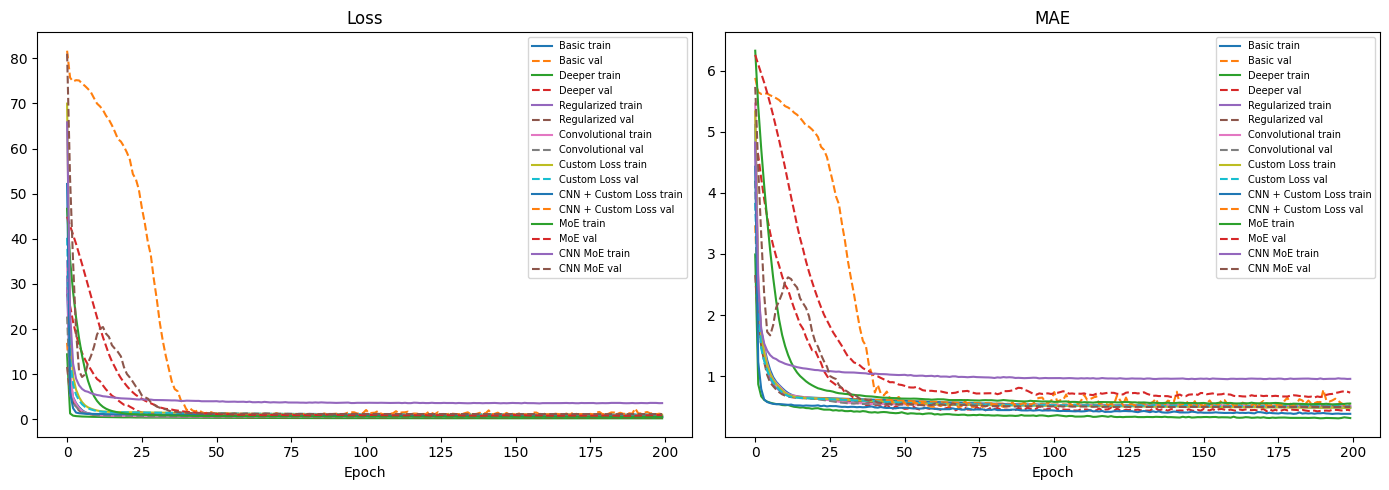

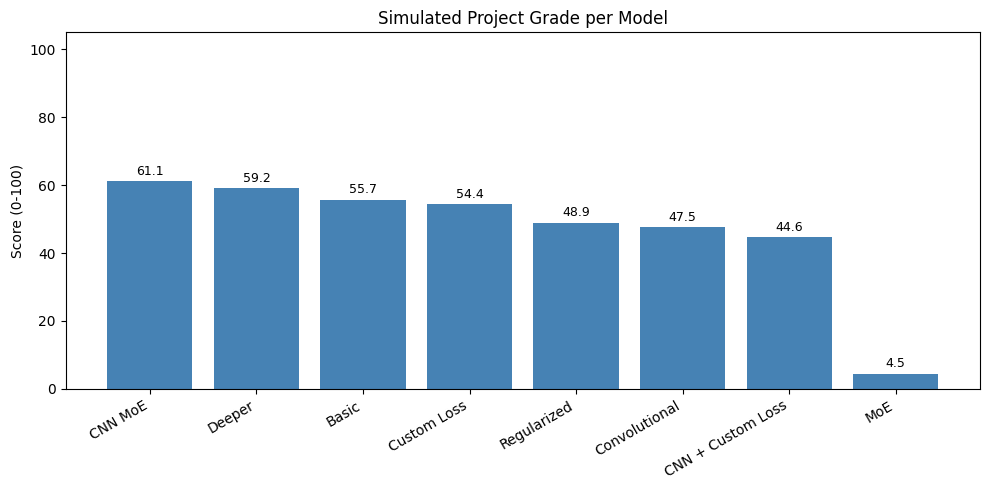

In [20]:
# === Evaluate ALL models using the project grading metric ===
# Cost per sample: sigma(y, y_hat) = (log2(y) - log2(y_hat))^2
# Predictions must be >= 1
# Grading: flipped sigmoid scored 0-100, parametrized by class median & quartile

import matplotlib.pyplot as plt

# ── helpers ──────────────────────────────────────────────────

def get_group_costs(y_pred_log, X_data, y_data):
    """Return dict mapping (k,m) -> avg cost for this model."""
    y_pred = np.exp(y_pred_log)
    y_actual = np.exp(y_data)
    y_pred = np.maximum(y_pred, 1.0)
    cost_per_sample = (np.log2(y_actual) - np.log2(y_pred)) ** 2
    group_costs = {}
    for k_val in [4, 5, 6]:
        for m_val in range(2, 10 - k_val):
            k_idx, m_idx = k_val - 4, m_val - 2
            mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
            if mask.sum() > 0:
                group_costs[(k_val, m_val)] = cost_per_sample[mask].mean()
    return group_costs

def grade_models(all_group_costs):
    """
    Simulate project grading as if each model were a different student.
    
    For each (k,m) group:
      θ = median cost across all 'students' (models)
      α = ln(3) / (θ - q25_cost)      where q25_cost = 25th percentile
      β = max{ (100/(e^{α(σ-θ)}+1) - 50) * 50/(100/(e^{-αθ}+1)-50) + 50, 0 }
    
    Final score = average β across all 9 groups.
    """
    model_names = list(all_group_costs.keys())
    groups = list(next(iter(all_group_costs.values())).keys())  # all (k,m) pairs
    
    # Per-group score for each model
    model_group_scores = {name: {} for name in model_names}
    
    for grp in groups:
        # Collect all models' costs for this group
        costs = np.array([all_group_costs[name][grp] for name in model_names])
        sorted_costs = np.sort(costs)
        M = len(sorted_costs)
        
        # θ = median cost, q25 = 25th-percentile cost
        theta = sorted_costs[int(np.ceil(M / 2)) - 1]
        q25 = sorted_costs[int(np.ceil(M / 4)) - 1]
        
        for name in model_names:
            sigma = all_group_costs[name][grp]
            if theta - q25 > 1e-12:
                alpha = np.log(3) / (theta - q25)
            else:
                # All models nearly identical → give full marks if cost ≤ theta
                alpha = 100.0  # steep sigmoid
            
            # Denominator normalization factor
            denom = 100.0 / (np.exp(-alpha * theta) + 1) - 50
            if abs(denom) < 1e-12:
                denom = 1e-12
            
            beta = max(
                (100.0 / (np.exp(alpha * (sigma - theta)) + 1) - 50) * 50.0 / denom + 50,
                0.0
            )
            model_group_scores[name][grp] = beta
    
    # Final score = average across groups
    final_scores = {}
    for name in model_names:
        final_scores[name] = np.mean(list(model_group_scores[name].values()))
    
    return model_group_scores, final_scores

# ── Collect predictions & per-group costs for every model ────

all_group_costs = {}

# Single-input models from the results dict
for name, (mdl, hist) in results.items():
    preds = mdl.predict(X_val, verbose=0).flatten()
    all_group_costs[name] = get_group_costs(preds, X_val, y_val)

# MoE (MLP experts)
if 'moe_models' in globals():
    moe_preds = predict_moe(moe_models, X_val)
    all_group_costs['MoE'] = get_group_costs(moe_preds, X_val, y_val)

# CNN MoE (if trained)
if 'cnn_moe_models' in globals():
    cnn_moe_preds = predict_cnn_moe(cnn_moe_models, X_val)
    all_group_costs['CNN MoE'] = get_group_costs(cnn_moe_preds, X_val, y_val)

# ── Grade all models ─────────────────────────────────────────

model_group_scores, final_scores = grade_models(all_group_costs)

# ── Detailed per-group table ─────────────────────────────────

groups = sorted(next(iter(all_group_costs.values())).keys())
model_names = list(all_group_costs.keys())

print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<22}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for name in model_names:
    row = f"{name:<22}"
    for grp in groups:
        row += f"  {all_group_costs[name][grp]:>7.4f}"
    print(row)

print(f"\n{'=' * 80}")
print(f"  PER-GROUP SCORE (0-100, higher = better)")
print(f"{'=' * 80}")
header = f"{'Model':<22}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for name in model_names:
    row = f"{name:<22}"
    for grp in groups:
        row += f"  {model_group_scores[name][grp]:>7.1f}"
    print(row)

# ── Final scores summary ─────────────────────────────────────

print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (simulated grading, 0-100)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10} {'Score':>8}")
print("-" * 42)
for name, score in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f} {score:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")

# ── Plot training curves for all models including MoE ────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single-input models
for name, (mdl, hist) in results.items():
    axes[0].plot(hist.history['loss'], label=f'{name} train')
    axes[0].plot(hist.history['val_loss'], '--', label=f'{name} val')
    axes[1].plot(hist.history['mae'], label=f'{name} train')
    axes[1].plot(hist.history['val_mae'], '--', label=f'{name} val')

# MoE: average loss/mae across the 9 experts per epoch.
# Early stopping means experts may have different history lengths —
# truncate to the shortest to keep arrays homogeneous before averaging.
def avg_moe_curves(histories):
    """Average training curves across all MoE experts, truncated to min length."""
    all_loss  = [h.history['loss']     for h in histories.values()]
    all_vloss = [h.history['val_loss'] for h in histories.values()]
    all_mae   = [h.history['mae']      for h in histories.values()]
    all_vmae  = [h.history['val_mae']  for h in histories.values()]
    min_len = min(len(x) for x in all_loss)
    all_loss  = [x[:min_len] for x in all_loss]
    all_vloss = [x[:min_len] for x in all_vloss]
    all_mae   = [x[:min_len] for x in all_mae]
    all_vmae  = [x[:min_len] for x in all_vmae]
    return (np.mean(all_loss, axis=0), np.mean(all_vloss, axis=0),
            np.mean(all_mae, axis=0), np.mean(all_vmae, axis=0))

loss, vloss, mae, vmae = avg_moe_curves(moe_histories)
axes[0].plot(loss, label='MoE train')
axes[0].plot(vloss, '--', label='MoE val')
axes[1].plot(mae, label='MoE train')
axes[1].plot(vmae, '--', label='MoE val')

if 'cnn_moe_histories' in globals():
    loss, vloss, mae, vmae = avg_moe_curves(cnn_moe_histories)
    axes[0].plot(loss, label='CNN MoE train')
    axes[0].plot(vloss, '--', label='CNN MoE val')
    axes[1].plot(mae, label='CNN MoE train')
    axes[1].plot(vmae, '--', label='CNN MoE val')

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── Bar chart of final scores ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
names_sorted = sorted(final_scores, key=final_scores.get, reverse=True)
scores_sorted = [final_scores[n] for n in names_sorted]
bars = ax2.bar(names_sorted, scores_sorted, color='steelblue')
ax2.set_ylabel('Score (0-100)')
ax2.set_title('Simulated Project Grade per Model')
ax2.set_ylim(0, 105)
for bar, s in zip(bars, scores_sorted):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{s:.1f}',
             ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 5 Choose an MOE based on the best models per group.

In [21]:

# ── Hybrid MoE: pick the best-performing model per (k, m) group ──

# Map each (k, m) to the model with lowest validation cost
best_model_map = {
    (4, 2): ('Deeper',          deeper_model),
    (4, 3): ('Deeper',          deeper_model),
    (4, 4): ('Deeper',          deeper_model),
    (4, 5): ('CNN + Custom Loss', cnn_custom_model),
    (5, 2): ('Deeper',          deeper_model),
    (5, 3): ('Deeper',          deeper_model),
    (5, 4): ('CNN + Custom Loss', cnn_custom_model),
    (6, 2): ('Deeper',          deeper_model),
    (6, 3): ('Convolutional',   conv_model),
}

print("Hybrid MoE assignment:")
for (k, m), (name, _) in sorted(best_model_map.items()):
    cost = all_group_costs[name][(k, m)]
    print(f"  k={k}, m={m} -> {name:<20s} (cost={cost:.4f})")

# ── Predict with the hybrid MoE ─────────────────────────────
def predict_hybrid_moe(best_model_map, X_data):
    predictions = np.zeros(len(X_data))
    for (k_val, m_val), (_, model) in best_model_map.items():
        k_idx = k_val - 4
        m_idx = m_val - 2
        mask = (X_data[:, k_idx] == 1) & (X_data[:, 3 + m_idx] == 1)
        if mask.sum() > 0:
            predictions[mask] = model.predict(X_data[mask], verbose=0).flatten()
    return predictions

hybrid_preds = predict_hybrid_moe(best_model_map, X_val)
all_group_costs['Hybrid MoE'] = get_group_costs(hybrid_preds, X_val, y_val)

# ── Re-grade with the new hybrid model included ─────────────
model_group_scores, final_scores = grade_models(all_group_costs)

# Print final scores
print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (with Hybrid MoE)")
print(f"{'=' * 60}")
print(f"{'Model':<22} {'Avg Cost':>10} {'Score':>8}")
print("-" * 42)
for name, score in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_cost = np.mean(list(all_group_costs[name].values()))
    print(f"{name:<22} {avg_cost:>10.6f} {score:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")


Hybrid MoE assignment:
  k=4, m=2 -> Deeper               (cost=0.2435)
  k=4, m=3 -> Deeper               (cost=0.2860)
  k=4, m=4 -> Deeper               (cost=0.6665)
  k=4, m=5 -> CNN + Custom Loss    (cost=2.5812)
  k=5, m=2 -> Deeper               (cost=0.2413)
  k=5, m=3 -> Deeper               (cost=0.4905)
  k=5, m=4 -> CNN + Custom Loss    (cost=2.9120)
  k=6, m=2 -> Deeper               (cost=0.4178)
  k=6, m=3 -> Convolutional        (cost=2.3047)


W0000 00:00:1773276307.694098   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694209   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694259   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694309   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694357   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694404   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694456   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694563   12804 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276307.694679   12804 gp


  FINAL MODEL SCORES (with Hybrid MoE)
Model                    Avg Cost    Score
------------------------------------------
Hybrid MoE               1.127059    78.2
CNN MoE                  1.166735    60.5
Basic                    1.253695    58.9
Deeper                   1.166549    57.5
Custom Loss              1.247585    56.9
Regularized              1.286498    50.3
Convolutional            1.297587    47.4
CNN + Custom Loss        1.293455    46.9
MoE                      1.939174     2.9

>>> Best model: Hybrid MoE  (score = 78.2/100)


W0000 00:00:1773276308.983541   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.983752   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.983896   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.983965   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.984272   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.984691   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.985036   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.985651   12806 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773276308.986025   12806 gp

## 5 Retrain the Hybrid MOE model with the larger dataset and compare again

In [22]:

# ── Load the larger generated dataset ────────────────────────
with open('/workspace/Homework/Project1/Generated_n_k_m_P', 'rb') as f:
    gen_data = pickle.load(f)
with open('/workspace/Homework/Project1/Generated_m-heights', 'rb') as f:
    gen_heights = pickle.load(f)

print(f"Generated dataset: {len(gen_data)} samples")

# 80/20 split
gen_train_data, gen_val_data, gen_train_heights, gen_val_heights = train_test_split(
    gen_data, gen_heights, test_size=0.2, random_state=42
)
print(f"Train: {len(gen_train_data)}, Val: {len(gen_val_data)}")

# Preprocess
X_train_gen = preprocess_features(gen_train_data)
y_train_gen = preprocess_labels(gen_train_heights)
X_val_gen   = preprocess_features(gen_val_data)
y_val_gen   = preprocess_labels(gen_val_heights)

print(f"X_train_gen: {X_train_gen.shape}, y_train_gen: {y_train_gen.shape}")
print(f"X_val_gen:   {X_val_gen.shape},   y_val_gen:   {y_val_gen.shape}")

# Build tf.data pipelines
BATCH_SIZE_GEN = 4096
ds_train_gen = (tf.data.Dataset.from_tensor_slices((X_train_gen, y_train_gen.astype('float32')))
                .cache().shuffle(len(X_train_gen), seed=42)
                .batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE))
ds_val_gen = (tf.data.Dataset.from_tensor_slices((X_val_gen, y_val_gen.astype('float32')))
              .cache().batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE))

# ── Create fresh model instances for the hybrid ──────────────
EPOCHS_GEN = 200

# 1) Deeper model (used for 6 groups)
print("\n" + "=" * 60)
print("Retraining: Deeper Model on generated data")
print("=" * 60)
deeper_gen = create_deeper_model()
deeper_gen_hist = deeper_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                                 epochs=EPOCHS_GEN, verbose=1)

# 2) CNN + Custom Loss model (used for k=4,m=5 and k=5,m=4)
print("\n" + "=" * 60)
print("Retraining: CNN + Custom Loss Model on generated data")
print("=" * 60)
cnn_custom_gen = create_cnn_custom_loss_model()
cnn_custom_gen_hist = cnn_custom_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                                          epochs=EPOCHS_GEN, verbose=1)

# 3) Convolutional model (used for k=6,m=3)
print("\n" + "=" * 60)
print("Retraining: Convolutional Model on generated data")
print("=" * 60)
conv_gen = create_convolutional_model()
conv_gen_hist = conv_gen.fit(ds_train_gen, validation_data=ds_val_gen,
                              epochs=EPOCHS_GEN, verbose=1)

# ── Assemble the retrained Hybrid MoE ────────────────────────
best_model_map_gen = {
    (4, 2): ('Deeper',            deeper_gen),
    (4, 3): ('Deeper',            deeper_gen),
    (4, 4): ('Deeper',            deeper_gen),
    (4, 5): ('CNN + Custom Loss', cnn_custom_gen),
    (5, 2): ('Deeper',            deeper_gen),
    (5, 3): ('Deeper',            deeper_gen),
    (5, 4): ('CNN + Custom Loss', cnn_custom_gen),
    (6, 2): ('Deeper',            deeper_gen),
    (6, 3): ('Convolutional',     conv_gen),
}

# ── Evaluate on ORIGINAL validation set for fair comparison ──
hybrid_gen_preds = predict_hybrid_moe(best_model_map_gen, X_val)
all_group_costs['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds, X_val, y_val)

# Also evaluate on the generated validation set
hybrid_gen_preds_gen = predict_hybrid_moe(best_model_map_gen, X_val_gen)
all_group_costs_gen = {}
all_group_costs_gen['Hybrid MoE (retrained)'] = get_group_costs(hybrid_gen_preds_gen, X_val_gen, y_val_gen)

# ── Re-grade all models (including retrained hybrid) ─────────
model_group_scores, final_scores = grade_models(all_group_costs)

groups = sorted(next(iter(all_group_costs.values())).keys())
print(f"\n{'=' * 80}")
print(f"  PER-GROUP AVERAGE COST  (lower = better)")
print(f"{'=' * 80}")
header = f"{'Model':<28}" + "".join(f"  k={k},m={m}" for k, m in groups)
print(header)
print("-" * len(header))
for nm in sorted(all_group_costs.keys()):
    row = f"{nm:<28}"
    for grp in groups:
        row += f"  {all_group_costs[nm][grp]:>7.4f}"
    print(row)

print(f"\n{'=' * 60}")
print(f"  FINAL MODEL SCORES (all models, 0-100)")
print(f"{'=' * 60}")
print(f"{'Model':<28} {'Avg Cost':>10} {'Score':>8}")
print("-" * 48)
for nm, sc in sorted(final_scores.items(), key=lambda x: -x[1]):
    avg_c = np.mean(list(all_group_costs[nm].values()))
    print(f"{nm:<28} {avg_c:>10.6f} {sc:>7.1f}")

best_name = max(final_scores, key=final_scores.get)
print(f"\n>>> Best model: {best_name}  (score = {final_scores[best_name]:.1f}/100)")


Generated dataset: 768364 samples
Train: 614691, Val: 153673
X_train_gen: (614691, 37), y_train_gen: (614691,)
X_val_gen:   (153673, 37),   y_val_gen:   (153673,)

Retraining: Deeper Model on generated data
Epoch 1/200


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 13/151 [=>............................] - ETA: 1s - loss: 16.2847 - mae: 3.3494

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


151/151 [==============================] - 4s 11ms/step - loss: 2.0490 - mae: 0.8475 - val_loss: 16.5526 - val_mae: 3.6309
Epoch 2/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5458 - mae: 0.5302 - val_loss: 6.0510 - val_mae: 2.0826
Epoch 3/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5289 - mae: 0.5204 - val_loss: 1.2231 - val_mae: 0.8104
Epoch 4/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5194 - mae: 0.5142 - val_loss: 0.5794 - val_mae: 0.5230
Epoch 5/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5089 - mae: 0.5071 - val_loss: 0.5626 - val_mae: 0.5402
Epoch 6/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5064 - mae: 0.5063 - val_loss: 0.5610 - val_mae: 0.5365
Epoch 7/200
151/151 [==============================] - 2s 10ms/step - loss: 0.5047 - mae: 0.5049 - val_loss: 0.5041 - val_mae: 0.5042
Epoch 8/200
151/151 [==============================] - 2s 10ms/step - los

...

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


151/151 [==============================] - 2s 6ms/step - loss: 9.8684 - mae: 2.1821 - val_loss: 1.0585 - val_mae: 0.7831
Epoch 2/200
151/151 [==============================] - 1s 5ms/step - loss: 0.7683 - mae: 0.6591 - val_loss: 0.6550 - val_mae: 0.6032
Epoch 3/200
151/151 [==============================] - 1s 5ms/step - loss: 0.6417 - mae: 0.5936 - val_loss: 0.6338 - val_mae: 0.5925
Epoch 4/200
151/151 [==============================] - 1s 5ms/step - loss: 0.6090 - mae: 0.5737 - val_loss: 0.5834 - val_mae: 0.5562
Epoch 5/200
151/151 [==============================] - 1s 5ms/step - loss: 0.5660 - mae: 0.5463 - val_loss: 0.5500 - val_mae: 0.5428
Epoch 6/200
151/151 [==============================] - 1s 5ms/step - loss: 0.5387 - mae: 0.5280 - val_loss: 0.5264 - val_mae: 0.5228
Epoch 7/200
151/151 [==============================] - 1s 5ms/step - loss: 0.5264 - mae: 0.5195 - val_loss: 0.5228 - val_mae: 0.5255
Epoch 8/200
151/151 [==============================] - 1s 5ms/step - loss: 0.5193

W0000 00:00:1773277468.795850   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796015   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796076   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796143   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796200   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796269   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796356   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796545   12807 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277468.796667   12807 gp


  PER-GROUP AVERAGE COST  (lower = better)
Model                         k=4,m=2  k=4,m=3  k=4,m=4  k=4,m=5  k=5,m=2  k=5,m=3  k=5,m=4  k=6,m=2  k=6,m=3
-------------------------------------------------------------------------------------------------------------
Basic                          0.4184   0.4212   0.7874   2.5467   0.4652   0.8196   2.8577   0.6262   2.3409
CNN + Custom Loss              0.3284   0.4280   0.7138   2.5812   0.4802   0.7552   2.9120   1.0356   2.4068
CNN MoE                        0.2286   0.2950   0.5848   2.6510   0.2888   0.6285   2.9468   0.4699   2.4071
Convolutional                  0.5255   0.4596   1.0199   2.6872   0.4418   0.8483   2.8116   0.5797   2.3047
Custom Loss                    0.4080   0.3897   0.8115   2.4910   0.4476   0.8051   2.8862   0.6264   2.3628
Deeper                         0.2435   0.2860   0.6665   2.6661   0.2413   0.4905   3.0734   0.4178   2.4138
Hybrid MoE                     0.2435   0.2860   0.6665   2.5811   0.2413   

W0000 00:00:1773277473.467771   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.467883   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.467931   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.467979   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.468029   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.468069   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.468117   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.468216   12805 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773277473.468286   12805 gp